# Benchmarking a Classical QSPR Pipeline across Multiple Molecular Properties

*Generalizability of an ECFP4 + XGBoost pipeline from aqueous solubility (logS) to hydration free energy (FreeSolv) and lipophilicity (logD), benchmarked against published graph neural networks.*

## Abstract

A classical QSPR pipeline combining ECFP4 fingerprints with six physicochemical descriptors and gradient-boosted trees, developed previously for aqueous solubility, is transferred without re-optimisation to two further MoleculeNet properties: hydration free energy (FreeSolv, n = 642) and lipophilicity (logD; Lipophilicity, n = 4200). Models are evaluated under both repeated 5-fold cross-validation and a Bemis-Murcko scaffold split, and compared against published graph neural networks. XGBoost attains R2 = 0.913 (RMSE 1.12 kcal/mol) on FreeSolv and R2 = 0.656 (RMSE 0.705) on Lipophilicity under random folds, competitive with message-passing networks on lipophilicity but well behind the best of them on hydration free energy, especially under scaffold-based evaluation where performance degrades sharply. A transfer experiment that appends a predicted logD feature to the solubility model yields no improvement, since the predicted value is largely redundant with the lipophilicity descriptor already present. The results delineate the ceiling of fixed-representation methods and motivate learned molecular representations.

## 1. Introduction

The prediction of physicochemical properties directly from molecular structure is a central task of quantitative structure-property relationship (QSPR) modelling and an early filter in computational drug discovery. A previous notebook established a classical pipeline, combining Morgan (ECFP4) fingerprints, six interpretable physicochemical descriptors and gradient-boosted trees, for aqueous solubility (logS) on the ESOL and AqSolDB datasets [Delaney, 2004]. The present work asks a deliberately narrow question: does the same pipeline, transferred without any re-optimisation, generalise to other molecular properties? To answer it, the approach is benchmarked on two additional MoleculeNet datasets [Wu et al., 2018] describing physically distinct quantities, the hydration free energy of FreeSolv [Mobley & Guthrie, 2014] and the octanol/water distribution coefficient of the Lipophilicity dataset [Hersey et al., 2015].

The three properties are related yet distinct, each isolating a different exchange of a molecule with its aqueous environment. Aqueous solubility (logS) describes the transfer of a compound from its crystalline solid to a saturated aqueous solution, and therefore combines two contributions: the energy required to disrupt the crystal lattice and the free energy of solvation of the isolated molecule. Hydration free energy (dG_hyd), the target of FreeSolv, describes the transfer of a molecule from the gas phase to water; because it starts from the gas phase it excludes the crystal-lattice term entirely and reports solvation in its purest form, with strongly negative values indicating high affinity for water. The distribution coefficient (logD), measured here at physiological pH 7.4, quantifies how a compound partitions between water and octanol, integrating over its ionisation states and thus capturing lipophilicity as it is experienced in vivo. Because logS, dG_hyd and logD probe overlapping but non-identical physics, a model that succeeds on one is not guaranteed to succeed on the others.

This non-equivalence is precisely what motivates benchmarking a single approach across several endpoints rather than reporting a strong result on one. Evaluating the same features and models on multiple properties reveals whether an approach is genuinely robust or merely well-suited to one task, and it exposes property-specific limitations, in the choice of representation, in the linearity of the structure-property relationship, and in the ability to generalise beyond the training chemistry, that a single-dataset study would leave hidden.

To place the classical pipeline in context, its performance is compared against published graph neural networks evaluated on the same datasets. On FreeSolv, reported test RMSE values are 1.40 kcal/mol for the message-passing neural network of MoleculeNet [Wu et al., 2018], 1.37 kcal/mol for the directed MPNN of Chemprop [Yang et al., 2019] and 0.736 kcal/mol for AttentiveFP [Xiong et al., 2020]; on Lipophilicity, the corresponding values are 0.672, 0.555 and 0.578 log units. These learned-representation models constitute the targets against which a fixed-representation, non-optimised baseline is measured throughout this notebook.

## 2. Data

Both datasets are loaded directly from the DeepChem/MoleculeNet distribution. FreeSolv is stored under its original name `SAMPL.csv`.

### 2.1 Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, KFold, cross_validate, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from collections import defaultdict
from xgboost import XGBRegressor

print("Libraries imported.")

Libraries imported.


### 2.2 FreeSolv (Mobley & Guthrie, 2014)

FreeSolv provides experimental and calculated hydration free energies for 642 small molecules. The experimental value (`expt`, in kcal/mol) is used as the target throughout; the calculated column (`calc`) is not used.

In [16]:
# FreeSolv (MoleculeNet / SAMPL): hydration free energy in kcal/mol
freesolv_url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/SAMPL.csv"
df_freesolv = pd.read_csv(freesolv_url)
print("FreeSolv shape:", df_freesolv.shape)
print("FreeSolv columns:", df_freesolv.columns.tolist())

FreeSolv shape: (642, 4)
FreeSolv columns: ['iupac', 'smiles', 'expt', 'calc']


### 2.3 Lipophilicity (Hersey et al., 2015)

The Lipophilicity dataset reports the octanol/water distribution coefficient (logD at pH 7.4) for 4200 compounds curated from ChEMBL. The target column is `exp`.

In [17]:
# Lipophilicity (AstraZeneca / MoleculeNet): logD at pH 7.4
lipo_url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
df_lipo = pd.read_csv(lipo_url)
print("Lipophilicity shape:", df_lipo.shape)
print("Lipophilicity columns:", df_lipo.columns.tolist())

Lipophilicity shape: (4200, 3)
Lipophilicity columns: ['CMPD_CHEMBLID', 'exp', 'smiles']


### 2.4 Target distributions

The two targets are summarised and their distributions compared below.

FreeSolv (dG_hyd, kcal/mol):
count    642.000000
mean      -3.803006
std        3.847820
min      -25.470000
25%       -5.727500
50%       -3.530000
75%       -1.215000
max        3.430000
Name: expt, dtype: float64

Lipophilicity (logD):
count    4200.000000
mean        2.186336
std         1.203004
min        -1.500000
25%         1.410000
50%         2.360000
75%         3.100000
max         4.500000
Name: exp, dtype: float64


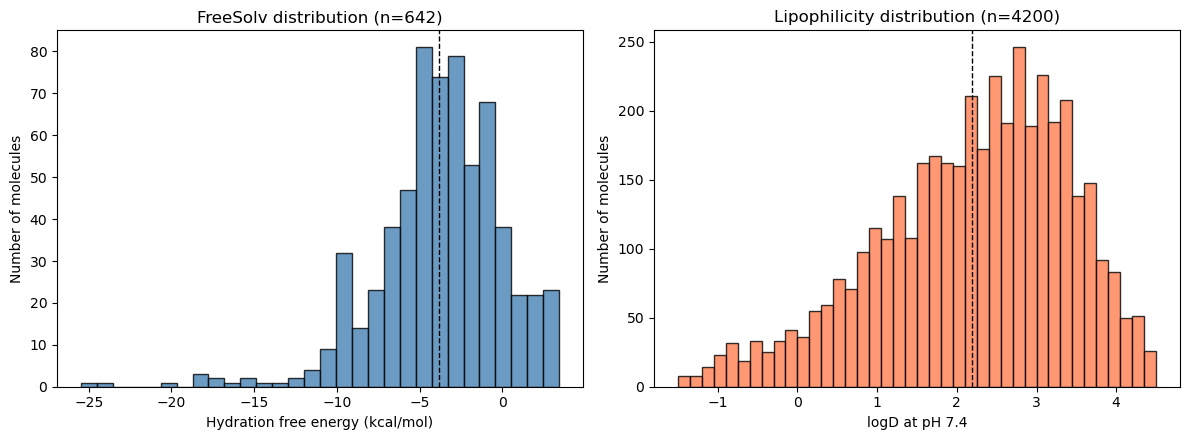

In [18]:
# Target and SMILES columns
freesolv_smiles = df_freesolv["smiles"]
freesolv_y = df_freesolv["expt"]   # experimental hydration free energy (kcal/mol)

lipo_smiles = df_lipo["smiles"]
lipo_y = df_lipo["exp"]            # logD at pH 7.4

print("FreeSolv (dG_hyd, kcal/mol):")
print(freesolv_y.describe())
print("\nLipophilicity (logD):")
print(lipo_y.describe())

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# FreeSolv
axes[0].hist(freesolv_y, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].axvline(freesolv_y.mean(), color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Hydration free energy (kcal/mol)")
axes[0].set_ylabel("Number of molecules")
axes[0].set_title("FreeSolv distribution (n=642)")

# Lipophilicity
axes[1].hist(lipo_y, bins=40, color="coral", edgecolor="black", alpha=0.8)
axes[1].axvline(lipo_y.mean(), color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("logD at pH 7.4")
axes[1].set_ylabel("Number of molecules")
axes[1].set_title("Lipophilicity distribution (n=4200)")

plt.tight_layout()
plt.show()

The Lipophilicity dataset is markedly larger than FreeSolv (4200 vs 642 molecules). FreeSolv is centered around -3.8 kcal/mol, with a sharp central peak but a long tail toward strongly negative values; although it spans a wide range of hydration free energies, these extreme values are represented by only a handful of molecules, so predictions in that region are expected to be unreliable. Lipophilicity, by contrast, shows a narrower but well-sampled and roughly symmetric distribution of logD values (about -1 to 4.5), which, combined with its larger size, should make it an easier target to model.

## 3. Methods

To ensure a fair, like-for-like comparison, the molecular representation, the models and their hyperparameters are kept identical to those of the earlier solubility notebook. Parameters are NOT re-optimised for the new datasets: any difference in performance therefore reflects the property and the data, not tuning.

### 3.1 Molecular representation

Each molecule is encoded as a 2054-dimensional vector: a 2048-bit ECFP4 Morgan fingerprint (radius 2) concatenated with six physicochemical descriptors (LogP, molecular weight, H-bond donors, H-bond acceptors, TPSA, number of aromatic rings). The helper `build_Xy` filters molecules whose SMILES cannot be parsed and re-aligns the target vector to the surviving molecules, preventing any feature/label misalignment.

In [19]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

def compute_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

def build_feature_matrix(smiles_series):
    desc_list = smiles_series.apply(compute_descriptors).tolist()
    valid_mask = [d is not None for d in desc_list]
    smiles_valid = smiles_series[valid_mask].reset_index(drop=True)
    descriptors = pd.DataFrame([d for d in desc_list if d is not None])
    fp_matrix = np.array([compute_fingerprint(s) for s in smiles_valid])
    X = np.hstack([fp_matrix, descriptors.values])
    return X, smiles_valid, descriptors

def build_Xy(smiles_series, target_series):
    X, smiles_valid, desc = build_feature_matrix(smiles_series)
    valid_mask = smiles_series.apply(lambda s: Chem.MolFromSmiles(s) is not None).values
    y = target_series[valid_mask].reset_index(drop=True)
    return X, y, smiles_valid, desc

X_freesolv, y_freesolv, freesolv_smiles_valid, freesolv_desc = build_Xy(freesolv_smiles, freesolv_y)
X_lipo, y_lipo, lipo_smiles_valid, lipo_desc = build_Xy(lipo_smiles, lipo_y)

print("FreeSolv X:", X_freesolv.shape, "| y:", y_freesolv.shape, "| dropped:", len(freesolv_smiles) - X_freesolv.shape[0])
print("Lipo     X:", X_lipo.shape, "| y:", y_lipo.shape, "| dropped:", len(lipo_smiles) - X_lipo.shape[0])

FreeSolv X: (642, 2054) | y: (642,) | dropped: 0
Lipo     X: (4200, 2054) | y: (4200,) | dropped: 0


### 3.2 Models

Three regressors are compared: linear regression (baseline), random forest and XGBoost, with the same defaults used previously (100 estimators; XGBoost learning rate 0.1).

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

### 3.3 Evaluation protocol

Two complementary schemes are used. Repeated 5-fold cross-validation (5 splits x 5 repeats = 25 evaluations) estimates in-domain performance with a mean and standard deviation. A Bemis-Murcko scaffold split, which places whole scaffolds entirely in either train or test, measures generalisation to unseen chemotypes and is generally more demanding. The functions below define both, together with an out-of-fold predicted-versus-measured plot.

In [21]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error"}
cv_pred = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_kfold(X, y, dataset_name):
    print("===", dataset_name, "(RepeatedKFold 5x5) ===")
    for name, model in models.items():
        res = cross_validate(model, X, y, cv=cv, scoring=scoring)
        r2 = res["test_r2"]
        rmse = -res["test_rmse"]
        print(name, "| R2:", round(r2.mean(), 3), "+/-", round(r2.std(), 3),
              "| RMSE:", round(rmse.mean(), 3), "+/-", round(rmse.std(), 3))

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

def scaffold_split(smiles_valid, test_frac=0.2):
    scaffolds = defaultdict(list)
    for i, smi in enumerate(smiles_valid):
        scaffolds[get_scaffold(smi)].append(i)
    # largest scaffolds go to train; rare ones end up in test (hardest case)
    groups = sorted(scaffolds.values(), key=len, reverse=True)
    n_train = int((1 - test_frac) * len(smiles_valid))
    train_idx, test_idx = [], []
    for group in groups:
        if len(train_idx) + len(group) <= n_train:
            train_idx += group
        else:
            test_idx += group
    return np.array(train_idx), np.array(test_idx)

def evaluate_scaffold(X, y, smiles_valid, dataset_name):
    y = np.asarray(y)
    train_idx, test_idx = scaffold_split(smiles_valid)
    print("===", dataset_name, "(scaffold split) ===")
    print("train:", len(train_idx), "| test:", len(test_idx))
    for name, model in models.items():
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        r2 = r2_score(y[test_idx], pred)
        rmse = mean_squared_error(y[test_idx], pred) ** 0.5
        print(name, "| R2:", round(r2, 3), "| RMSE:", round(rmse, 3))

def plot_pred_vs_true(X, y, dataset_name, color, unit):
    y = np.asarray(y)
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    y_pred = cross_val_predict(model, X, y, cv=cv_pred)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred) ** 0.5
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y, y_pred, s=12, alpha=0.4, color=color)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    plt.plot(lims, lims, "k--", linewidth=1)
    plt.xlabel("Measured " + unit)
    plt.ylabel("Predicted " + unit)
    plt.title(dataset_name + " - XGBoost out-of-fold\nR2 = " + str(round(r2, 3)) + ", RMSE = " + str(round(rmse, 3)))
    plt.tight_layout()
    plt.show()

## 4. Results

### 4.1 Chemical space

Before modelling, the chemical space spanned by the two datasets is visualised by principal component analysis of the standardized feature matrix. Standardization is required because the six descriptors and the binary fingerprint bits differ by orders of magnitude in scale.

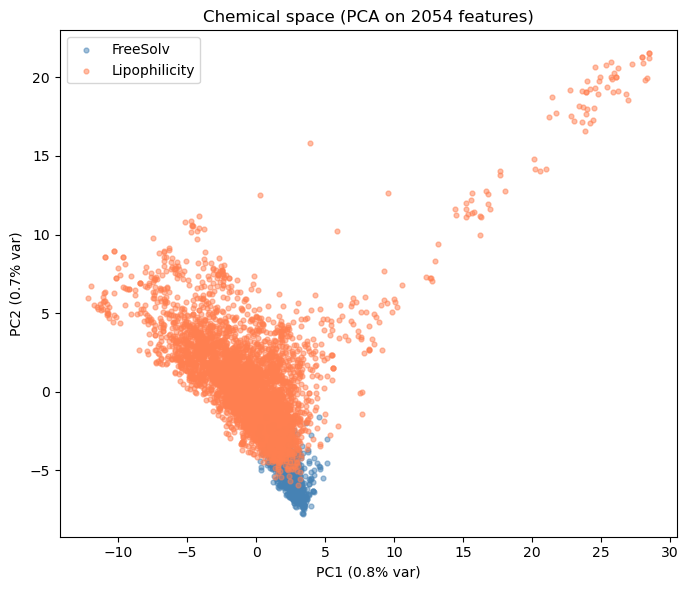

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Shared 2D space across both datasets
X_combined = np.vstack([X_freesolv, X_lipo])
labels = np.array(["FreeSolv"] * len(X_freesolv) + ["Lipophilicity"] * len(X_lipo))

X_scaled = StandardScaler().fit_transform(X_combined)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(coords[labels == "FreeSolv", 0], coords[labels == "FreeSolv", 1],
            s=12, alpha=0.5, color="steelblue", label="FreeSolv")
plt.scatter(coords[labels == "Lipophilicity", 0], coords[labels == "Lipophilicity", 1],
            s=12, alpha=0.5, color="coral", label="Lipophilicity")
plt.xlabel("PC1 (" + str(round(pca.explained_variance_ratio_[0] * 100, 1)) + "% var)")
plt.ylabel("PC2 (" + str(round(pca.explained_variance_ratio_[1] * 100, 1)) + "% var)")
plt.title("Chemical space (PCA on 2054 features)")
plt.legend()
plt.tight_layout()
plt.show()

Principal component analysis of the pooled, standardized feature matrix yields first two components capturing only ~1.5% of the total variance, consistent with the high intrinsic dimensionality of Morgan fingerprints, whose structural information is distributed across many weakly correlated bits. The projection therefore resolves broad trends rather than fine structure. FreeSolv clusters within a compact, low-molecular-weight region, whereas Lipophilicity occupies a markedly broader and more diverse domain extending to heavier, drug-like scaffolds. The FreeSolv distribution falls almost entirely inside the Lipophilicity manifold, indicating partial but asymmetric overlap: a substantial fraction of the Lipophilicity chemical space lies beyond the domain sampled by FreeSolv.

### 4.2 FreeSolv

=== FreeSolv (RepeatedKFold 5x5) ===
Linear Regression | R2: 0.868 +/- 0.036 | RMSE: 1.369 +/- 0.187
Random Forest | R2: 0.894 +/- 0.028 | RMSE: 1.235 +/- 0.213
XGBoost | R2: 0.913 +/- 0.018 | RMSE: 1.12 +/- 0.149
=== FreeSolv (scaffold split) ===
train: 513 | test: 129
Linear Regression | R2: 0.713 | RMSE: 2.686
Random Forest | R2: 0.514 | RMSE: 3.493
XGBoost | R2: 0.588 | RMSE: 3.217


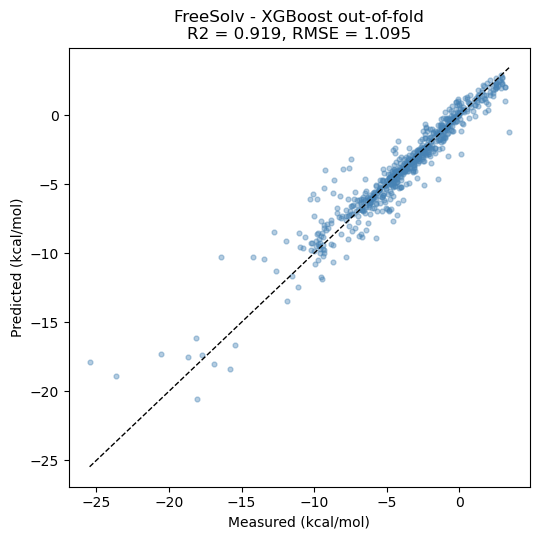

In [23]:
evaluate_kfold(X_freesolv, y_freesolv, "FreeSolv")
evaluate_scaffold(X_freesolv, y_freesolv, freesolv_smiles_valid, "FreeSolv")
plot_pred_vs_true(X_freesolv, y_freesolv, "FreeSolv", "steelblue", "(kcal/mol)")

Under repeated cross-validation, XGBoost is the strongest model on FreeSolv (R2 = 0.913, RMSE 1.12 kcal/mol), ahead of Random Forest (0.894) and Linear Regression (0.868), and its RMSE already improves on the MPNN and D-MPNN benchmarks (1.40 and 1.37 kcal/mol). The picture changes under the scaffold split: XGBoost degrades to RMSE 3.22 (R2 = 0.588) and, notably, the model ranking inverts, with Linear Regression (RMSE 2.69) outperforming both ensembles. This indicates that the tree models exploit fingerprint patterns specific to the training scaffolds, whereas the linear model, resting on continuous physicochemical descriptors, extrapolates more gracefully to unseen chemotypes. The out-of-fold prediction plot confirms the expected failure mode: predictions cluster tightly around the diagonal in the well-populated region but systematically underestimate the magnitude of the most negative (most hydrophilic) values, which are represented by only a handful of molecules.

### 4.3 Lipophilicity

=== Lipophilicity (RepeatedKFold 5x5) ===
Linear Regression | R2: -0.008 +/- 0.149 | RMSE: 1.202 +/- 0.074
Random Forest | R2: 0.666 +/- 0.02 | RMSE: 0.694 +/- 0.027
XGBoost | R2: 0.656 +/- 0.017 | RMSE: 0.705 +/- 0.021
=== Lipophilicity (scaffold split) ===
train: 3360 | test: 840
Linear Regression | R2: -0.607 | RMSE: 1.526
Random Forest | R2: 0.552 | RMSE: 0.806
XGBoost | R2: 0.542 | RMSE: 0.815


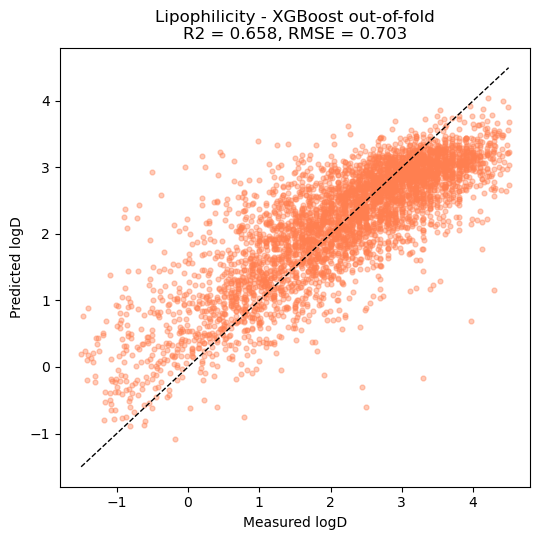

In [24]:
evaluate_kfold(X_lipo, y_lipo, "Lipophilicity")
evaluate_scaffold(X_lipo, y_lipo, lipo_smiles_valid, "Lipophilicity")
plot_pred_vs_true(X_lipo, y_lipo, "Lipophilicity", "coral", "logD")

Lipophilicity shows a different profile. XGBoost and Random Forest perform almost identically (RMSE 0.705 and 0.694; R2 around 0.66), close to the MPNN benchmark (0.672) though behind D-MPNN and AttentiveFP (0.555 and 0.578). The gap between random and scaffold evaluation is small (RMSE 0.705 vs 0.815), reflecting the dataset's larger size and greater scaffold diversity, which keep most test molecules within the applicability domain. Strikingly, Linear Regression collapses here (R2 close to 0 under cross-validation, negative under the scaffold split), the opposite of its behaviour on FreeSolv: logD depends on non-linear, substructure-specific effects that only the tree ensembles capture, whereas hydration free energy is nearly additive in the chosen descriptors. The prediction plot shows the characteristic regression toward the mean of a model with limited explanatory power, underestimating high logD values and overestimating low ones.

### 4.4 Benchmark comparison

| Dataset | Model / method | Protocol | RMSE | R2 |
|---|---|---|---|---|
| FreeSolv (kcal/mol) | Linear Regression | RepeatedKFold 5x5 | 1.37 | 0.868 |
| | Random Forest | RepeatedKFold 5x5 | 1.24 | 0.894 |
| | **XGBoost (this work)** | RepeatedKFold 5x5 | **1.12** | **0.913** |
| | **XGBoost (this work)** | Scaffold split | **3.22** | **0.588** |
| | MPNN [Wu 2018] | reported | 1.40 | - |
| | D-MPNN [Yang 2019] | reported | 1.37 | - |
| | AttentiveFP [Xiong 2020] | reported | 0.736 | - |
| Lipophilicity (logD) | Linear Regression | RepeatedKFold 5x5 | 1.20 | -0.01 |
| | Random Forest | RepeatedKFold 5x5 | 0.69 | 0.666 |
| | **XGBoost (this work)** | RepeatedKFold 5x5 | **0.705** | **0.656** |
| | **XGBoost (this work)** | Scaffold split | **0.815** | **0.542** |
| | MPNN [Wu 2018] | reported | 0.672 | - |
| | D-MPNN [Yang 2019] | reported | 0.555 | - |
| | AttentiveFP [Xiong 2020] | reported | 0.578 | - |

In [25]:
benchmark = pd.DataFrame([
    ["FreeSolv",      "XGBoost + ECFP4 (this work)", "RepeatedKFold 5x5", 1.12],
    ["FreeSolv",      "XGBoost + ECFP4 (this work)", "Scaffold split",    3.22],
    ["FreeSolv",      "MPNN (Wu 2018)",              "reported",          1.40],
    ["FreeSolv",      "D-MPNN (Yang 2019)",          "reported",          1.37],
    ["FreeSolv",      "AttentiveFP (Xiong 2020)",    "reported",          0.736],
    ["Lipophilicity", "XGBoost + ECFP4 (this work)", "RepeatedKFold 5x5", 0.705],
    ["Lipophilicity", "XGBoost + ECFP4 (this work)", "Scaffold split",    0.815],
    ["Lipophilicity", "MPNN (Wu 2018)",              "reported",          0.672],
    ["Lipophilicity", "D-MPNN (Yang 2019)",          "reported",          0.555],
    ["Lipophilicity", "AttentiveFP (Xiong 2020)",    "reported",          0.578],
], columns=["Dataset", "Method", "Protocol", "RMSE"])

print(benchmark.to_string(index=False))

      Dataset                      Method          Protocol  RMSE
     FreeSolv XGBoost + ECFP4 (this work) RepeatedKFold 5x5 1.120
     FreeSolv XGBoost + ECFP4 (this work)    Scaffold split 3.220
     FreeSolv              MPNN (Wu 2018)          reported 1.400
     FreeSolv          D-MPNN (Yang 2019)          reported 1.370
     FreeSolv    AttentiveFP (Xiong 2020)          reported 0.736
Lipophilicity XGBoost + ECFP4 (this work) RepeatedKFold 5x5 0.705
Lipophilicity XGBoost + ECFP4 (this work)    Scaffold split 0.815
Lipophilicity              MPNN (Wu 2018)          reported 0.672
Lipophilicity          D-MPNN (Yang 2019)          reported 0.555
Lipophilicity    AttentiveFP (Xiong 2020)          reported 0.578


### 4.5 Transfer experiment: predicted logD as an added feature

This experiment tests whether transferring lipophilicity information can improve solubility prediction. A logD model is trained on the full Lipophilicity dataset and used to predict logD for every ESOL molecule; the predicted value is then appended as an extra feature before re-predicting logS. The overlap between the two datasets is also quantified to justify the transfer design.

In [26]:
# --- ESOL (as in notebook 01) ---
esol_url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df_esol = pd.read_csv(esol_url)
esol_smiles = df_esol["smiles"]
esol_y = df_esol["measured log solubility in mols per litre"]
X_esol, y_esol, esol_smiles_valid, esol_desc = build_Xy(esol_smiles, esol_y)

# 1. logD model trained on the FULL Lipophilicity dataset
logD_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
logD_model.fit(X_lipo, np.asarray(y_lipo))

# 2. Predict logD for every ESOL molecule (same 2054 features, same column order)
esol_pred_logD = logD_model.predict(X_esol)

# 3. Append as an additional feature
X_esol_plus = np.hstack([X_esol, esol_pred_logD.reshape(-1, 1)])

# 4. Baseline vs augmented, same CV
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
base = cross_validate(xgb, X_esol, np.asarray(y_esol), cv=cv, scoring=scoring)
aug  = cross_validate(xgb, X_esol_plus, np.asarray(y_esol), cv=cv, scoring=scoring)

print("ESOL baseline (2054 feat) | R2:", round(base["test_r2"].mean(), 3), "+/-", round(base["test_r2"].std(), 3))
print("ESOL + pred logD (2055)   | R2:", round(aug["test_r2"].mean(), 3), "+/-", round(aug["test_r2"].std(), 3))

# Diagnostic: is the predicted logD redundant with the LogP descriptor?
corr = np.corrcoef(esol_pred_logD, esol_desc["LogP"].values)[0, 1]
print("corr(predicted logD, LogP descriptor):", round(corr, 3))

ESOL baseline (2054 feat) | R2: 0.898 +/- 0.014
ESOL + pred logD (2055)   | R2: 0.899 +/- 0.015
corr(predicted logD, LogP descriptor): 0.876


In [27]:
def canonical(smi):
    m = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(m) if m else None

esol_canon = set(esol_smiles.map(canonical).dropna())
lipo_canon = set(lipo_smiles.map(canonical).dropna())
print("Molecules present in BOTH ESOL and Lipophilicity:", len(esol_canon & lipo_canon))

Molecules present in BOTH ESOL and Lipophilicity: 50


To test whether transferring lipophilicity information could improve aqueous solubility prediction, a logD model trained on the full Lipophilicity dataset was used to predict logD for every ESOL molecule, and this predicted value was appended as an additional feature. The augmented model showed no meaningful gain over the baseline (R2 = 0.899 vs 0.898, well within one standard deviation). This outcome is expected: the predicted logD correlates strongly with the MolLogP descriptor already present in the feature set (r = 0.876), so it carries almost no information the model did not already have. Adding features does not add predictive power when the new variable is largely redundant with existing ones. Notably, ESOL and Lipophilicity share only 50 molecules, far too few to build a model on their intersection, which is precisely why an externally trained predictor, rather than measured logD, was used here.

## 5. Discussion

Across the three properties examined, aqueous solubility (logS), hydration free energy (ΔG_hyd) and lipophilicity (logD), the same XGBoost pipeline built on ECFP4 fingerprints and six physicochemical descriptors ranked first among the tested models under random cross-validation, yet the three tasks differed markedly in achievable accuracy and in how they responded to model choice. Under RepeatedKFold, XGBoost reached R² = 0.898 on ESOL (this work; [Delaney, 2004]), R² = 0.913 (RMSE 1.12 kcal/mol) on FreeSolv, and R² = 0.656 (RMSE 0.705) on Lipophilicity. These figures are not directly comparable across properties, as each uses different units and spans a different range, but they already show that a single feature-and-model recipe does not behave uniformly across endpoints.

FreeSolv proved the most demanding benchmark despite describing a physically simpler process. Hydration free energy is defined from the gas phase and therefore excludes the crystal-lattice contribution that complicates solid solubility; nonetheless, the dataset is small (642 molecules) and its experimental values carry an intrinsic uncertainty of the order of 0.6 kcal/mol [Mobley & Guthrie, 2014], which sets a floor below which no model can improve. The strongly negative tail of the distribution is represented by only a handful of molecules, and the predicted-versus-measured plot confirms that the model systematically underestimates the magnitude of hydration in this region. The best published graph network on this set, AttentiveFP (RMSE 0.736 [Xiong et al., 2020]), already operates close to this noise floor, leaving little room for any method.

Lipophilicity showed the opposite profile. With 4200 molecules covering a broad and well-populated region of chemical space, it produced the smallest gap between random and scaffold-based evaluation (RMSE 0.705 vs 0.815 for XGBoost), reflecting a training set diverse enough to keep most test scaffolds within the applicability domain. Yet logD was the least amenable to linear modelling: linear regression collapsed to R² close to 0 under cross-validation and to -0.607 under the scaffold split, whereas it remained strong on FreeSolv (R² = 0.868). This inversion indicates that hydration free energy is nearly additive in the chosen physicochemical descriptors, while logD is governed by more non-linear, substructure-specific effects that only the tree-based models could exploit. The ranking of models is therefore property-dependent, which is the central argument for benchmarking an approach across several endpoints rather than one.

The results also delineate where the two-dimensional representation reaches its limits. It is blind to the crystal packing that governs part of solid solubility, and, more visibly here, the sparse fingerprint bits generalise poorly to unseen scaffolds: on FreeSolv the XGBoost RMSE degraded from 1.12 under random folds to 3.22 under a scaffold split, and in that regime the simpler linear model, relying on continuous and transferable descriptors, outperformed both ensembles. This is precisely the regime in which message-passing networks excel, as they learn a continuous molecular representation instead of depending on a fixed vocabulary of substructural bits [Yang et al., 2019; Xiong et al., 2020]. Such comparisons must nonetheless be read with care, since the published network scores were obtained under their own splitting protocols; the two evaluation regimes reported here are shown side by side to avoid a misleading claim. Finally, the Option B experiment illustrated a related point about representation: appending an externally predicted logD to the ESOL feature set left performance unchanged (R² = 0.899 vs 0.898), because the added variable was largely redundant (r = 0.876) with the MolLogP descriptor already present. Additional features improve a model only when they carry information it does not already hold.

## 6. Conclusion

A classical QSPR pipeline combining ECFP4 fingerprints with six physicochemical descriptors and gradient-boosted trees, transferred without re-optimisation from an earlier solubility study, was benchmarked on two additional MoleculeNet properties. XGBoost was the strongest model in every in-domain evaluation, reaching R2 = 0.913 (RMSE 1.12 kcal/mol) on FreeSolv and R2 = 0.656 (RMSE 0.705) on Lipophilicity under repeated cross-validation. On Lipophilicity the approach is competitive with published graph neural networks; on FreeSolv it trails the strongest of them and, more tellingly, collapses under a scaffold split (RMSE 3.22), where a plain linear model on physical descriptors generalises better than the ensembles. The study further shows that both task difficulty and the optimal model are property-dependent, that two-dimensional descriptors are intrinsically limited for endpoints governed by solid-state or three-dimensional effects, and that appending a redundant engineered feature (predicted logD, r = 0.876 with MolLogP) does not improve solubility prediction. Together these results outline the ceiling of fixed-representation methods and motivate the learned, transferable representations of message-passing networks as the natural next step, which will be explored in a subsequent notebook.

## References

[1] Mobley, D.L. & Guthrie, J.P. FreeSolv: a database of experimental and calculated hydration free energies, with input files. J. Comput.-Aided Mol. Des. 28, 711-720 (2014). DOI: 10.1007/s10822-014-9747-x

[2] Hersey, A. et al. ChEMBL lipophilicity dataset. DOI: 10.6019/CHEMBL3301361 (2015).

[3] Wu, Z. et al. MoleculeNet: a benchmark for molecular machine learning. Chem. Sci. 9, 513-530 (2018). DOI: 10.1039/C7SC02664A

[4] Yang, K. et al. Analyzing learned molecular representations for property prediction. J. Chem. Inf. Model. 59, 3370-3388 (2019). DOI: 10.1021/acs.jcim.9b00237

[5] Xiong, Z. et al. Pushing the boundaries of molecular representation for drug discovery with the graph attention mechanism. J. Med. Chem. 63, 8749-8760 (2020). DOI: 10.1021/acs.jmedchem.9b00959

[6] Delaney, J.S. ESOL: estimating aqueous solubility directly from molecular structure. J. Chem. Inf. Comput. Sci. 44, 1000-1005 (2004). DOI: 10.1021/ci034243x